In [1]:
import networkx as nx
import numpy as np
import torch

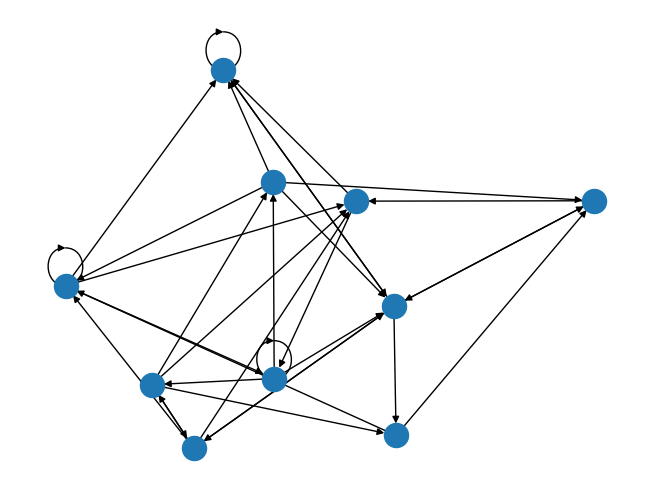

In [2]:
G1 = nx.read_edgelist('lab1_small_edgelist.txt',create_using=nx.DiGraph(),nodetype=None,data=[('weight',int)])
nx.draw(G1)

In [3]:
A_torch = torch.randint(0, 2, (10, 10))
A_np = np.random.randint(2, size=(15, 15))

def build_graph(adj_matrix):
    graph = nx.DiGraph()  # note nx.Graph() v.s. nx.DiGraph()
    for i in range(len(adj_matrix)):
        for j in range(len(adj_matrix[i])):
            if adj_matrix[i][j] == 1:
                graph.add_edge(i, j)
            if i == j:
                graph.add_edge(i, j)
    return graph

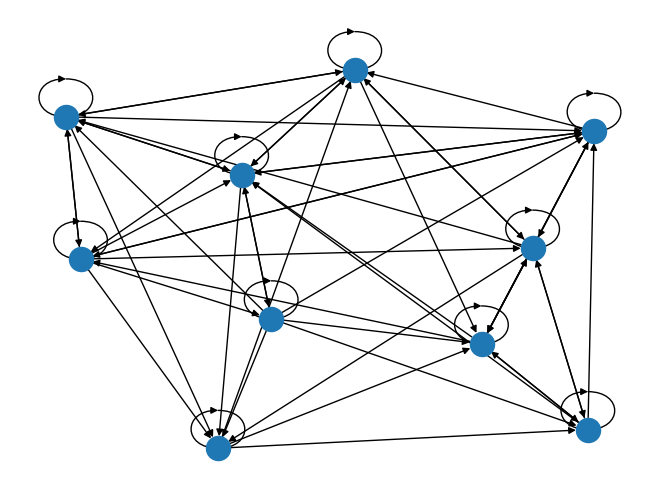

In [4]:
G2 = build_graph(A_torch)
nx.draw(G2)

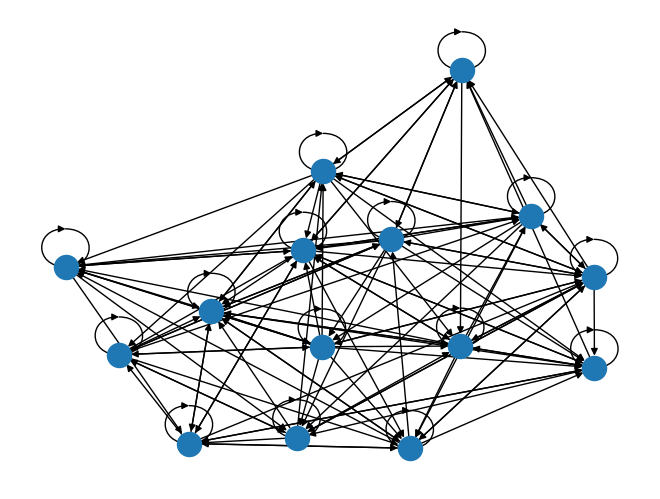

In [5]:
G3 = build_graph(A_np)
nx.draw(G3)

In [5]:
import networkx as nx
from joblib import Parallel, delayed
import random
import itertools
import numpy as np
from gensim.models import Word2Vec

In [6]:
def partition_num(num, workers):
    if num % workers == 0:
        return [num//workers]*workers
    else:
        return [num//workers]*workers + [num % workers]

### Model: DeepWalk

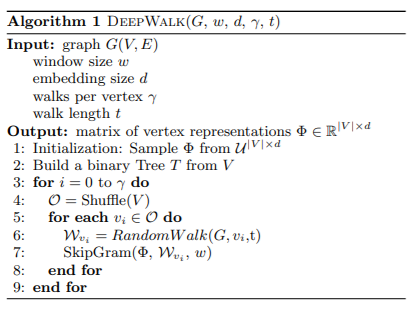

In [7]:
class RandomWalker:
  def __init__(self, G, num_walks, walk_length):
      self.G = G
      self.num_walks = num_walks
      self.walk_length = walk_length


  def deepwalk_walk(self, start_node):
      walk = [start_node]
      while len(walk) < self.walk_length:
          cur = walk[-1]
          # Check if having any neighbors at the current node
          cur_nbrs = list(self.G.neighbors(cur))
          if len(cur_nbrs) > 0:
              # Random walk with the probability of 1/d(v^t). d(v^t) is the node degree
              walk.append(random.choice(cur_nbrs))
          else:
              break
      return walk


  def simulate_walks(self, workers=1, verbose=0):
      G = self.G
      nodes = list(G.nodes())
      results = Parallel(n_jobs=workers, verbose=verbose)(
          delayed(self._simulate_walks)(nodes) for num in
          partition_num(self.num_walks, workers))
      walks = list(itertools.chain(*results))
      return walks

  def _simulate_walks(self, nodes):
      walks = []
      for _ in range(self.num_walks):
          random.shuffle(nodes)
          for v in nodes:
            walks.append(self.deepwalk_walk(start_node=v))
      return walks

In [12]:
class DeepWalk:
    def __init__(self, graph, walk_length, num_walks, workers=1):

        self.graph = graph
        self.w2v_model = None
        self._embeddings = {}

        self.walker = RandomWalker(graph, num_walks=num_walks, walk_length=walk_length)
        self.sentences = self.walker.simulate_walks(workers=workers, verbose=1)

    def train(self, embed_size=128, window_size=5, workers=1, iter=5, **kwargs):

        kwargs["sentences"] = self.sentences
        kwargs["min_count"] = kwargs.get("min_count", 0)
        kwargs["vector_size"] = embed_size  
        kwargs["sg"] = 1  
        kwargs["hs"] = 1  
        kwargs["workers"] = workers
        kwargs["window"] = window_size
        kwargs["epochs"] = iter 

        print("Learning embedding vectors...")
        model = Word2Vec(**kwargs)
        print("Learning embedding vectors done!")

        self.w2v_model = model
        return model


    def get_embeddings(self,):
        if self.w2v_model is None:
            print("model not train")
            return {}

        self._embeddings = {}
        for word in self.graph.nodes():
            self._embeddings[word] = self.w2v_model.wv[word]

        return self._embeddings

In [13]:
G = nx.read_edgelist('lab1_big_edgelist.txt',create_using=nx.DiGraph(),nodetype=None,data=[('weight',int)])
model = DeepWalk(G,walk_length=10,num_walks=80,workers=1)
model.train(window_size=5,iter=3)
embeddings = model.get_embeddings()

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.4s finished


Learning embedding vectors...
Learning embedding vectors done!


In [14]:
count = 0
for i, (k, v) in enumerate(embeddings.items()):
  print("Index {} has key {} and value {}".format(str(i), k, v))
  count += 1
  if count == 2:
    break

Index 0 has key 1397 and value [ 0.08852403 -0.37886107 -0.23893237 -0.0715038   0.4690194  -0.0891818
  0.15575443 -0.35645372  0.27471155  0.49816033  0.13265775  0.01719175
 -0.17011741 -0.29343453 -0.53918064  0.49551696 -0.09947298  0.50876427
  0.2416101   0.53219837  0.12029187 -0.0440222  -0.34272367 -0.44312164
 -0.0974886   0.22052516 -0.06789173 -0.0501049   0.00825211  0.73338497
  0.09647506 -0.49453688  0.21671519  0.04692468  0.1809188   0.1220632
  0.1861323   0.08490562 -0.18905643  0.61093724 -0.15932816 -0.14352216
  0.70459193 -0.64012337  0.22743712 -0.0413379  -0.1965945  -0.00279643
  0.0642955  -0.48710835  0.623464    0.06565722  0.21043657  0.10297273
 -0.16911587  0.20182948  0.13372493  0.06918556  0.08843908  0.00972947
 -0.5068529   0.17803042  0.14241667  0.24230216  0.19421121  0.1304607
  0.07035939  0.2982502  -0.1318227   0.45548633 -0.14161718  0.26543084
 -0.08518479 -0.25877133  0.25085807 -0.1459553   0.36386257 -0.15696655
 -0.5455437   0.5289971